## Mount Drive

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load Clean Dataset

In [22]:
data_path = "/content/drive/MyDrive/Fatigue-Life-ML/data/processed/fatigue_dataset_clean.csv"

df = pd.read_csv(data_path)

df.head()

,base_yield_strength,base_ultimate_strength,welding_joint,welding_method,welding_voltage,welding_current,welding_speed,fatigue_specimen_type,fatigue_specimen_thickness,residual_stress,stress_concentration,load_ratio,stress_range,fatigue_life,stress_amplitude,mean_stress,normalized_stress,stress_strength_ratio,log_fatigue_life
0,355.0,575.0,Butt Joint,GMAW (MAG - Metal Active Gas Welding),27.5,290.0,10.00,Standard,8.0,210.0,1.78,0.1,185.0,2000000.0,92.5,101.75,0.521127,0.321739,6.301030
1,355.0,575.0,Butt Joint,GMAW (MAG - Metal Active Gas Welding),27.5,290.0,10.00,Standard,8.0,210.0,1.78,0.1,220.0,2000000.0,110.0,121.00,0.619718,0.382609,6.301030
2,890.0,1025.0,Cone-Cylinder Welded Joint,Manual Arc Welding,112.0,23.0,2.08,Typical CCPS Welded Joint Specimen,22.0,200.0,1.78,0.1,89.0,36400.0,44.5,48.95,0.100000,0.086829,4.561101
3,890.0,1025.0,Cone-Cylinder Welded Joint,Manual Arc Welding,112.0,23.0,2.08,Typical CCPS Welded Joint Specimen,22.0,200.0,1.78,0.1,89.0,31363.0,44.5,48.95,0.100000,0.086829,4.496418
4,890.0,1025.0,Cone-Cylinder Welded Joint,Manual Arc Welding,112.0,23.0,2.08,Typical CCPS Welded Joint Specimen,22.0,200.0,1.78,0.1,89.0,23461.0,44.5,48.95,0.100000,0.086829,4.370347


## Dataset Overview

In [23]:
df.shape

(45124, 19)

### The dataset contains 45,315 fatigue experiments with 18 features describing structural and loading characteristics of welded joints. This dataset size provides a strong foundation for developing data-driven fatigue life prediction models.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45124 entries, 0 to 45123
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   base_yield_strength         45124 non-null  float64
 1   base_ultimate_strength      45124 non-null  float64
 2   welding_joint               45124 non-null  object 
 3   welding_method              45124 non-null  object 
 4   welding_voltage             45124 non-null  float64
 5   welding_current             45124 non-null  float64
 6   welding_speed               45124 non-null  float64
 7   fatigue_specimen_type       45124 non-null  object 
 8   fatigue_specimen_thickness  45124 non-null  float64
 9   residual_stress             45124 non-null  float64
 10  stress_concentration        45124 non-null  float64
 11  load_ratio                  45124 non-null  float64
 12  stress_range                45124 non-null  float64
 13  fatigue_life                451

### The dataset contains both numerical and categorical variables. Numerical features represent material properties, stress parameters, and geometric characteristics of welded joints, while categorical features describe welding processes and specimen configurations.

In [25]:
df.describe()

,base_yield_strength,base_ultimate_strength,welding_voltage,welding_current,welding_speed,fatigue_specimen_thickness,residual_stress,stress_concentration,load_ratio,stress_range,fatigue_life,stress_amplitude,mean_stress,normalized_stress,stress_strength_ratio,log_fatigue_life
count,45124.000000,45124.000000,45124.000000,45124.000000,45124.000000,45124.000000,45124.000000,45124.000000,45124.000000,4.512400e+04,4.512400e+04,4.512400e+04,4.512400e+04,45124.000000,45124.000000,45124.000000
mean,466.457018,580.317332,1111.659126,277.427227,11.710174,10.485675,204.296731,1.906446,0.272439,1.140479e+03,1.950572e+07,5.702393e+02,6.589859e+02,2.821699,2.514022,5.570311
std,228.213107,235.388930,11742.799588,1079.210044,72.296878,47.502141,69.180131,2.462438,0.478158,5.946771e+04,1.098865e+09,2.973385e+04,3.270723e+04,149.226238,111.070152,0.924593
min,17.060000,1.000000,2.000000,0.000000,0.010000,0.050000,0.000000,0.940000,0.000000,1.000000e+00,2.000000e+00,5.000000e-01,5.500000e-01,0.002941,0.002381,0.301030
25%,355.000000,506.000000,24.000000,185.000000,5.500000,4.000000,200.000000,1.780000,0.100000,1.280000e+02,1.160000e+05,6.400000e+01,7.500000e+01,0.312500,0.251899,5.064458
50%,400.000000,540.000000,24.000000,185.000000,5.500000,8.000000,200.000000,1.780000,0.100000,2.130000e+02,3.956810e+05,1.065000e+02,1.249500e+02,0.503650,0.398148,5.597345
75%,485.000000,579.000000,24.000000,185.000000,5.500000,12.000000,200.000000,1.780000,0.100000,3.400000e+02,1.284128e+06,1.700000e+02,2.101000e+02,0.791857,0.596296,6.108608
max,2024.000000,3724.000000,150000.000000,24100.000000,3000.000000,2024.000000,2391.000000,108.900000,10.000000,1.000000e+07,1.990000e+11,5.000000e+06,5.500000e+06,25000.000000,18518.518519,11.298853


### The statistical summary provides descriptive statistics for the numerical features, including measures such as mean, standard deviation, and range. These statistics provide an overview of the distribution and variability of key variables related to fatigue behavior.

## Target Transformation

### Fatigue life represents the number of load cycles required for a welded joint to fail. Fatigue life can span several orders of magnitude depending on loading conditions and material properties, resulting in a highly skewed distribution.

To improve the suitability of the target variable for machine learning models, a logarithmic transformation is applied to the fatigue life values.

In [26]:
df["log_fatigue_life"] = np.log10(df["fatigue_life"])

In [27]:
df[["fatigue_life","log_fatigue_life"]].head()

,fatigue_life,log_fatigue_life
0,2000000.0,6.301030
1,2000000.0,6.301030
2,36400.0,4.561101
3,31363.0,4.496418
4,23461.0,4.370347


### The transformed variable log_fatigue_life is used as the target variable for subsequent analysis and machine learning modeling.

## Fatigue Life Distribution

### The distribution of the fatigue life variable is analyzed to understand its range and variability. Since fatigue life spans several orders of magnitude, the logarithmically transformed variable (log_fatigue_life) is used for analysis.

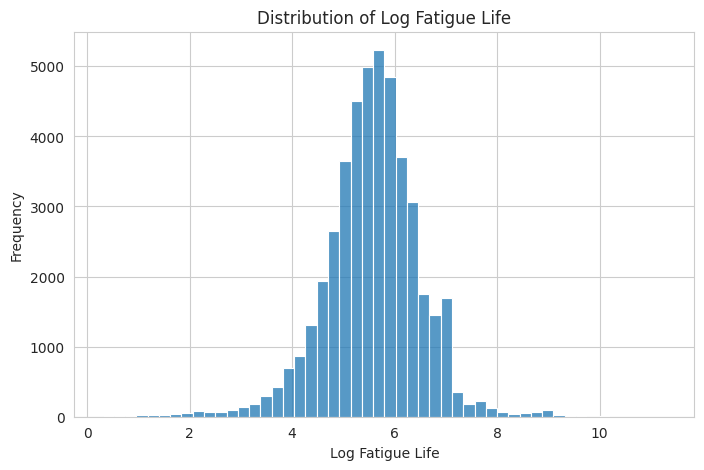

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df["log_fatigue_life"], bins=50)

plt.xlabel("Log Fatigue Life")
plt.ylabel("Frequency")

plt.title("Distribution of Log Fatigue Life")

# Save the plot
plt.savefig("/content/drive/MyDrive/Fatigue-Life-ML/results/fatigue_life_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### The log-transformed fatigue life values show a more symmetric distribution with reduced skewness, making the target variable more suitable for machine learning regression models.

## S-N Curve

### The S-N curve represents the relationship between stress range and fatigue life in structural components. In fatigue mechanics, higher stress levels typically result in lower fatigue life. Analyzing this relationship helps verify that the dataset reflects expected fatigue behavior.

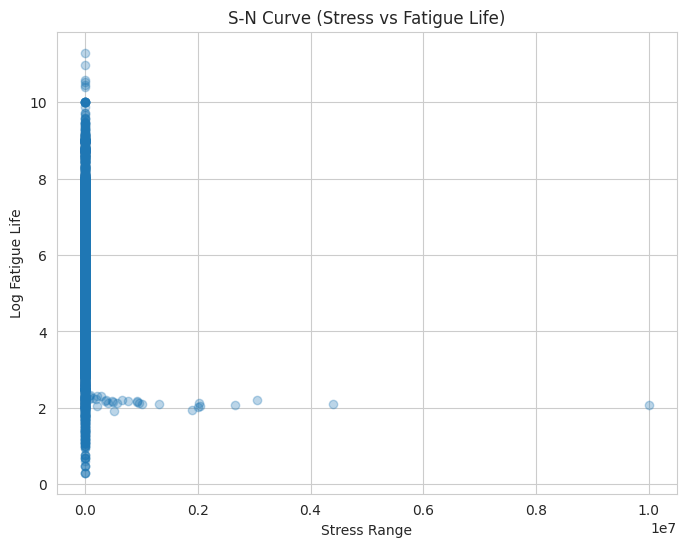

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(df["stress_range"], df["log_fatigue_life"], alpha=0.3)

plt.xlabel("Stress Range")
plt.ylabel("Log Fatigue Life")

plt.title("S-N Curve (Stress vs Fatigue Life)")

# Save the plot
plt.savefig("/content/drive/MyDrive/Fatigue-Life-ML/results/sn_curve_plot.png",
            dpi=300, bbox_inches="tight")

plt.show()

### The scatter plot illustrates the relationship between stress range and log fatigue life. A general tendency of decreasing fatigue life with increasing stress levels can be observed, although the relationship is influenced by variability in material properties, welding conditions, and loading parameters.

## Correlation Analysis

### Correlation analysis is performed to examine relationships between numerical features in the dataset. Understanding these relationships helps identify variables that may influence fatigue life and provides insight into potential predictors for machine learning models.

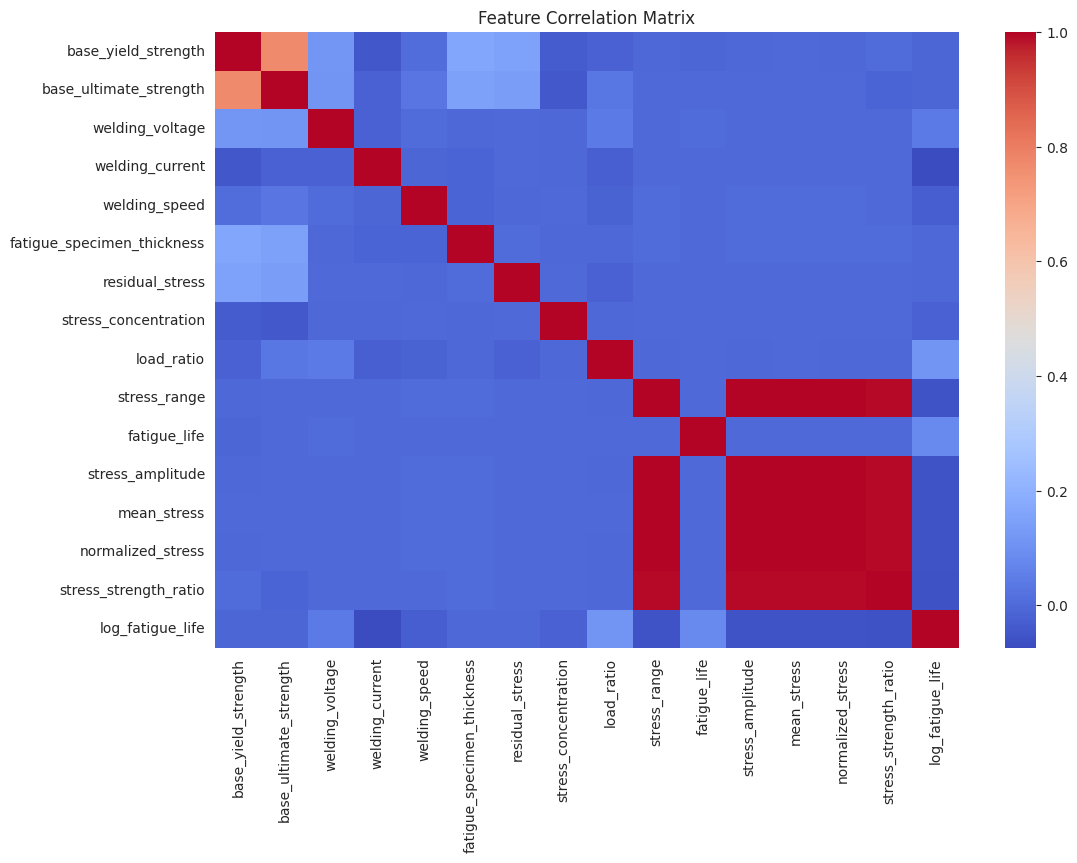

In [30]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

# Save the plot
plt.savefig("/content/drive/MyDrive/Fatigue-Life-ML/results/feature_correlation_matrix.png",
            dpi=300, bbox_inches="tight")

plt.show()

### The correlation matrix highlights relationships among material properties, stress parameters, and fatigue life. Strong correlations are observed among stress-related variables due to their mathematical relationships, while fatigue life shows weaker correlations with individual predictors.

## Welding Method Influence

### The influence of welding methods on fatigue life is analyzed to evaluate how different welding processes affect the structural performance of welded joints. Variations in welding techniques can lead to differences in residual stresses, weld quality, and geometric imperfections, which may impact fatigue behavior.

In [31]:
def simplify_welding(method):

    method = str(method).lower()

    if "laser" in method:
        return "Laser Welding"

    elif "mig" in method or "tig" in method or "arc" in method:
        return "Arc Welding"

    elif "hybrid" in method:
        return "Hybrid Welding"

    else:
        return "Other"

df["welding_group"] = df["welding_method"].apply(simplify_welding)

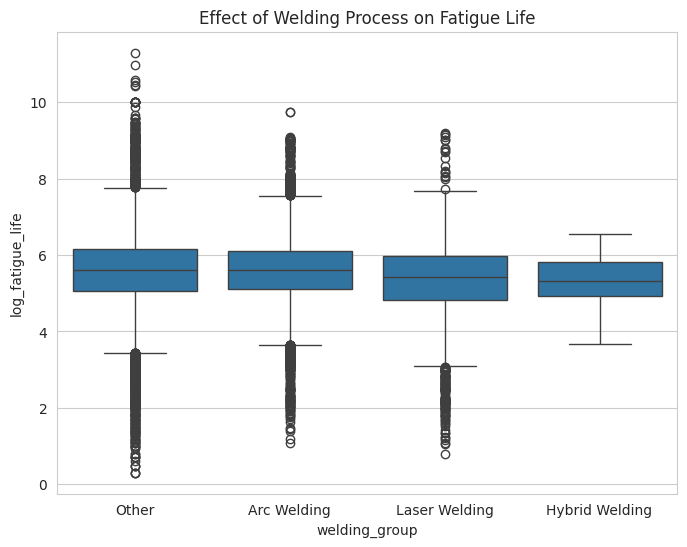

In [38]:
plt.figure(figsize=(8,6))

sns.boxplot(x="welding_group", y="log_fatigue_life", data=df)

plt.title("Effect of Welding Process on Fatigue Life")

plt.savefig("/content/drive/MyDrive/Fatigue-Life-ML/results/welding_process_fatigue_life.png",
            dpi=300, bbox_inches="tight")

plt.show()

### The boxplot illustrates the distribution of log fatigue life across different welding methods. While the median fatigue life values appear similar across groups, variations and outliers are present, which may reflect differences in welding processes, heat input, and resulting residual stresses in welded joints.

## Residual Stress Effect

### Residual stresses are commonly introduced during welding due to thermal expansion and cooling processes. These stresses can significantly influence the fatigue performance of welded joints. Analyzing the relationship between residual stress and fatigue life helps evaluate the potential impact of residual stress on fatigue behavior.

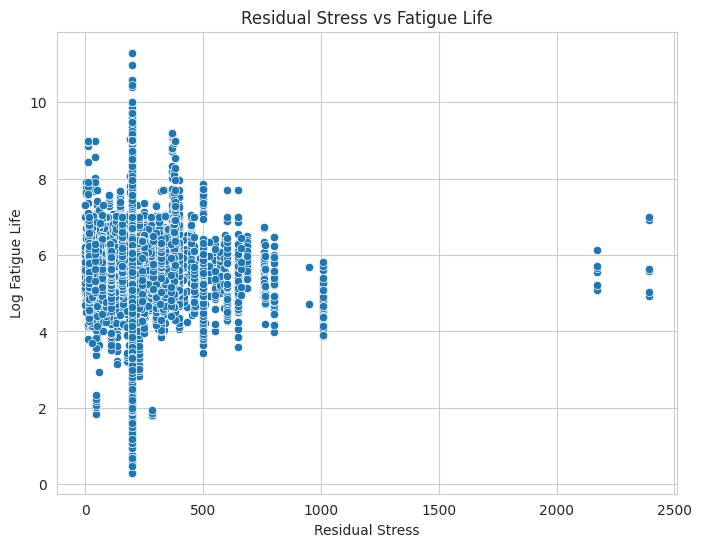

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="residual_stress", y="log_fatigue_life", data=df)

plt.xlabel("Residual Stress")
plt.ylabel("Log Fatigue Life")

plt.title("Residual Stress vs Fatigue Life")

plt.savefig("/content/drive/MyDrive/Fatigue-Life-ML/results/residual_stress_vs_fatigue_life.png",
            dpi=300, bbox_inches="tight")

plt.show()

### The scatter plot illustrates the relationship between residual stress and log fatigue life. Although a clear trend is not strongly visible, variations in residual stress may influence fatigue behavior in welded structures. Tensile residual stresses are known to promote crack initiation and propagation in fatigue loading conditions.

## Outlier Analysis

### Outlier analysis is performed to examine extreme values in the dataset that may influence model performance. Identifying potential outliers helps ensure that the dataset reflects realistic fatigue behavior and does not contain anomalous measurements that could bias machine learning models.

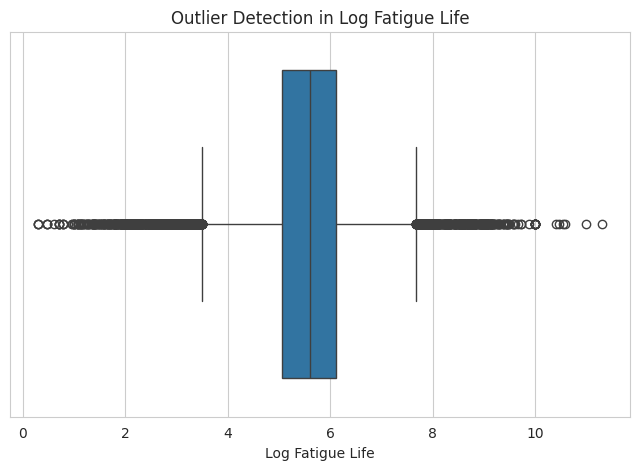

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["log_fatigue_life"])

plt.title("Outlier Detection in Log Fatigue Life")
plt.xlabel("Log Fatigue Life")

plt.savefig(
    "/content/drive/MyDrive/Fatigue-Life-ML/results/outlier_detection_log_fatigue_life.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### The boxplot indicates the presence of several extreme values in the fatigue life distribution.
Such variability is common in fatigue datasets due to differences in loading conditions, material properties, and experimental setups.

Since fatigue life can vary over several orders of magnitude, these extreme observations are retained in the dataset to preserve the full range of structural behavior.

## Feature Distribution Analysis

### The distributions of key stress-related variables are examined to understand their variability and scale within the dataset.
Since stress parameters in fatigue experiments can span several orders of magnitude, the resulting distributions are highly skewed.

This analysis highlights the wide range of loading conditions represented in the dataset and confirms that these stress-related variables are important predictors of fatigue behavior.

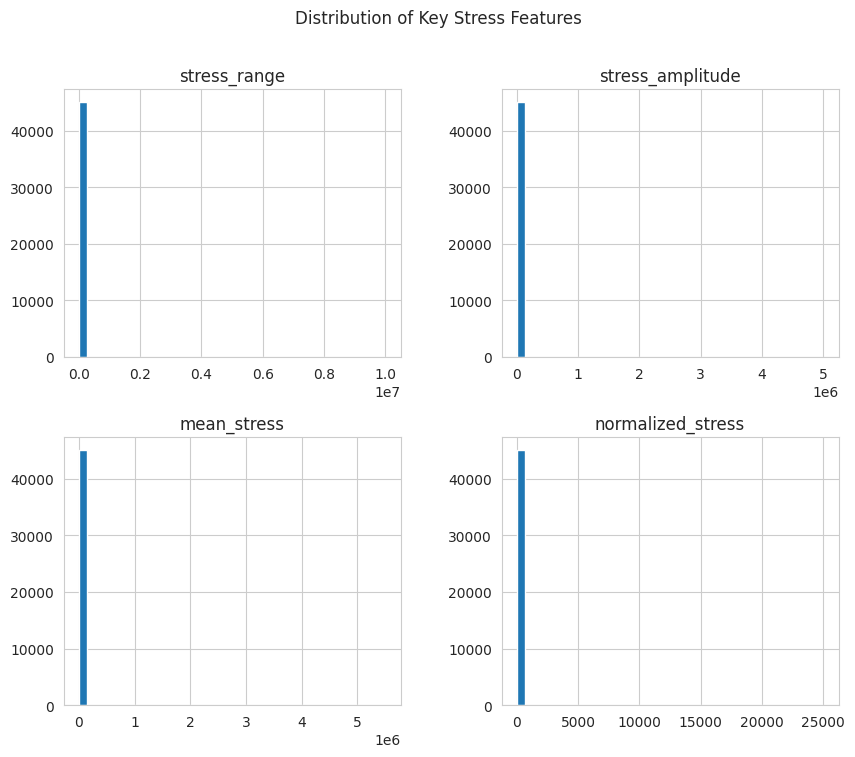

In [35]:
features = [
    "stress_range",
    "stress_amplitude",
    "mean_stress",
    "normalized_stress"
]

df[features].hist(figsize=(10,8), bins=40)

plt.suptitle("Distribution of Key Stress Features")

plt.savefig(
    "/content/drive/MyDrive/Fatigue-Life-ML/results/stress_feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### The histograms indicate that stress-related variables exhibit highly skewed distributions, with most observations concentrated at lower stress values and a smaller number of high-stress cases.

Such distributions are typical in fatigue datasets, where experiments are performed under a wide range of loading conditions. These variables capture important mechanical characteristics that influence fatigue crack initiation and propagation.

## Material Property Influence

### The scatter plot shows the relationship between base material yield strength (x-axis) and log fatigue life (y-axis).


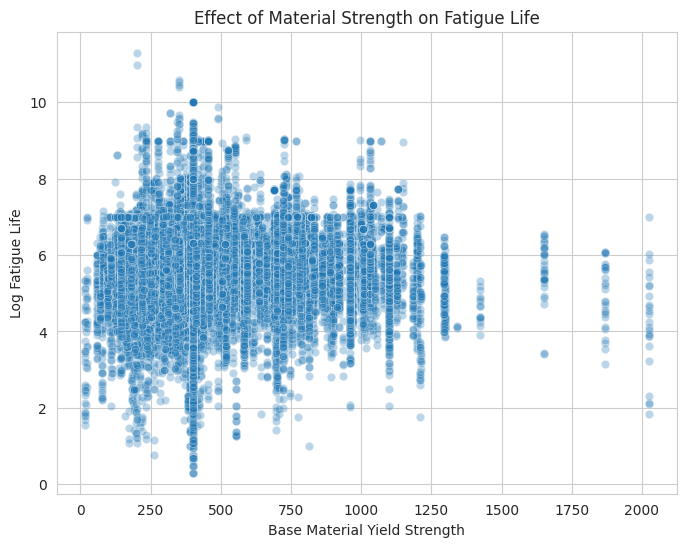

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="base_yield_strength",
    y="log_fatigue_life",
    data=df,
    alpha=0.3
)

plt.xlabel("Base Material Yield Strength")
plt.ylabel("Log Fatigue Life")

plt.title("Effect of Material Strength on Fatigue Life")

plt.savefig(
    "/content/drive/MyDrive/Fatigue-Life-ML/results/material_strength_vs_fatigue_life.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### The points are widely scattered across the range of material strengths, and a clear trend is not visible. This indicates that material yield strength alone does not strongly determine fatigue life, and fatigue performance is likely influenced by other factors such as stress conditions, welding parameters, and residual stresses.

## Geometry Influence

### The scatter plot shows the relationship between fatigue specimen thickness (x-axis) and log fatigue life (y-axis).

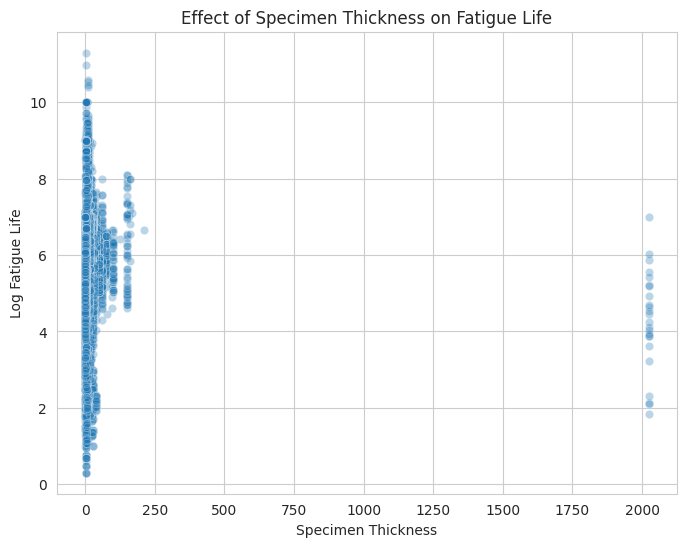

In [39]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="fatigue_specimen_thickness",
    y="log_fatigue_life",
    data=df,
    alpha=0.3
)

plt.xlabel("Specimen Thickness")
plt.ylabel("Log Fatigue Life")

plt.title("Effect of Specimen Thickness on Fatigue Life")

plt.savefig(
    "/content/drive/MyDrive/Fatigue-Life-ML/results/specimen_thickness_vs_fatigue_life.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Most observations are concentrated at lower specimen thickness values, with a few samples at very high thickness levels. The points are widely scattered, and no clear trend between specimen thickness and fatigue life is visible, suggesting that thickness alone may not strongly determine fatigue life in this dataset.